# Tutorial 6: From a Lumped Oscillator Model to readout parameters

Tutorials 1 and 2 fit a lumped `L`–`C` model to a CPW resonator and check how
accurately it reproduces the full distributed response. 

In this tutorial, you will learn how to turning that `L` and `C` into quantities 
you might actually use for designing a superconducting circuit. We will use the two helpers, `resonator_readout_params` and
`extract_f0_kappa`, to do the following:

1. Convert a fitted model into a resonance frequency $f_r$, characteristic
  impedance $Z_r$, and zero-point voltage and current fluctuations
2. Measure the loaded linewidth $\kappa$ and get the quality factor $Q$ 

3. Design a symmetric $C_c$ to match a target $Q$


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import skrf as rf

import simpleLOMs as sl

sl.apply_style()


## 1. Fit a resonator and read off its `L` and `C`

We use a 7 mm CPW resonator on an ultracold-silicon chip. The  `fit_lom(d, model=...)`  returns effective `L` and `C` for any of
the three models (`"optimized"`, `"foster"`, `"analytical"`). In this tutorial, we use Optimized, which is the
default and the most accurate. However, you can  switch `MODEL` below if you want a faster
Foster or Analytical fit.


In [3]:
cpw = sl.CPWParams(ep_r=11.45)                       # ultracold-silicon substrate
freq = rf.Frequency(4e9, 12e9, 8001, unit="Hz")

MODEL = "optimized"                               # or "foster" / "analytical"
L, C = sl.fit_lom(7e-3, model=MODEL, cpw_params=cpw, freq=freq)

print("Fitted lumped model ({}):".format(MODEL))
print("  L = {:.4f} nH".format(L * 1e9))
print("  C = {:.2f} fF".format(C * 1e15))


Fitted lumped model (optimized):
  L = 0.5605 nH
  C = 633.14 fF


## 2. Convert fitted `L`, `C` to relevant circuit parameters.

One of the benefits of lumped oscillator models is that they can be easily used to convert to Hamiltonian parameters using standard circuit quantization techniques.


### 2a. Unloaded quantities

To convert `L, C` to frequency, impedance, and zero-point fluctuations, use `resonator_readout_params(L, C)` to get these values based on the fitted `L, C` quantities.  

$$
\omega_r = \frac{1}{\sqrt{LC}}, \qquad
Z_r = \sqrt{\frac{L}{C}}, \qquad
V_\mathrm{zpf} = \sqrt{\frac{\hbar\omega_r}{2C}}, \qquad
I_\mathrm{zpf} = \sqrt{\frac{\hbar\omega_r}{2L}}.
$$

$Z_r$ and the zero-point fluctuations depend **only** on `L` and `C`, so we can
compute them before saying anything about loss or coupling.


In [4]:
rp = sl.resonator_readout_params(L, C)
print(rp.summary())


Resonator readout parameters
----------------------------
  f_r        =     8.4486 GHz
  Z_r        =      29.75 Ohm
  L          =     0.5605 nH
  C          =   633.1379 fF
  V_zpf      =      2.103 uV
  I_zpf      =     70.667 nA


$V_\mathrm{zpf}$ is on the order of a few $\mu$V and $I_\mathrm{zpf}$ is on the order of
tens of nA, as expected for a standard coplanar readout resonator.


### 2b. Loaded quantities ($\kappa$, $Q$)

The quality factor $Q$ is not a property of the bare mode. Instead it is set
by how strongly we couple the mode to the environment. 

In this geometry, the coupling capacitor $C_c$ ties the resonator to the 50 $\Omega$ feedline and
gives the mode a finite linewidth. We measure it using a circle fit via `extract_f0_kappa`, which
locates the resonance on a coarse grid, then re-simulates a narrow window on a
fine grid and reads $f_0$ and $\kappa$ from a circle fit (a single wide grid
cannot resolve a sub-MHz linewidth).


Beginning with a 6 fF coupling capacitor, we'll extract $f_0$ and $\kappa$ fo the CPW system.


In [ ]:
Cc = 6e-15                                       
f0, kappa = sl.extract_f0_kappa(cpw, d=7e-3, Cc=Cc)
print("measured:  f0 = {:.4f} GHz    kappa/2pi = {:.4f} MHz".format(f0/1e9, kappa/1e6))


measured:  f0 = 8.3697 GHz    kappa/2pi = 2.4586 MHz

Resonator readout parameters
----------------------------
  f_r        =     8.4486 GHz
  Z_r        =      29.75 Ohm
  L          =     0.5605 nH
  C          =   633.1379 fF
  V_zpf      =      2.103 uV
  I_zpf      =     70.667 nA
  kappa/2pi  =     2.4586 MHz
  Q (loaded) =       3436
  tau_photon =       64.7 ns


### 2c. Summarize the results


In [ ]:
rp = sl.resonator_readout_params(L, C, kappa_Hz=kappa)
print()
print(rp.summary())


Because this chip is lossless (`tand = 0`, superconducting metal), the internal
quality factor is effectively infinite and the loaded $Q$ is set entirely by the
coupling — i.e. here $Q \approx Q_c$, the **coupling quality factor**. On a real
device the loaded $Q$ combines with the internal $Q_i$ as
$Q_\ell^{-1} = Q_c^{-1} + Q_i^{-1}$.

The photon lifetime $\tau = 1/(2\pi\kappa) \approx 65$ ns is the readout
resonator's ring-down time.


## 3. Setting a design to match a target parameter. 

Here we will use the example of showing how the coupling capacitor $C_c$ sets $\kappa$ and $Q$ to show how you can use sweeps like this to correlate geometric features of your circuit design to actual desired parameters.


### 3a. Set up the sweep


We'll use 8 Cc values with all else fixed, and use `extract_f0_kappa` to get $\kappa$ an subsequently $Q$ 


In [6]:
Cc_values = np.linspace(2e-15, 16e-15, 8)
f0s, kappas, Qs = [], [], []
for Cc in Cc_values:
    f0, kappa = sl.extract_f0_kappa(cpw, d=7e-3, Cc=Cc)
    rp = sl.resonator_readout_params(L, C, kappa_Hz=kappa)
    f0s.append(f0 / 1e9)
    kappas.append(kappa / 1e6)
    Qs.append(rp.Q)

f0s, kappas, Qs = map(np.array, (f0s, kappas, Qs))
for cc, k, q in zip(Cc_values, kappas, Qs):
    print("Cc = {:4.1f} fF    kappa/2pi = {:7.3f} MHz    Q = {:8.0f}".format(cc*1e15, k, q))


Cc =  2.0 fF    kappa/2pi =   0.279 MHz    Q =    30272
Cc =  4.0 fF    kappa/2pi =   1.104 MHz    Q =     7656
Cc =  6.0 fF    kappa/2pi =   2.459 MHz    Q =     3436
Cc =  8.0 fF    kappa/2pi =   4.328 MHz    Q =     1952
Cc = 10.0 fF    kappa/2pi =   6.696 MHz    Q =     1262
Cc = 12.0 fF    kappa/2pi =   9.547 MHz    Q =      885
Cc = 14.0 fF    kappa/2pi =  12.865 MHz    Q =      657
Cc = 16.0 fF    kappa/2pi =  16.636 MHz    Q =      508


### 3b. (Optional) Validate the data

We already know approximately what to expect from this data based on approximate formulas. For 
a capacitively coupled resonator we expect that expectation is $\kappa \propto C_c^2$ and
therefore $Q \propto 1/C_c^2$. To ensure that this pattern occured, we can plot the two of them in log scale:


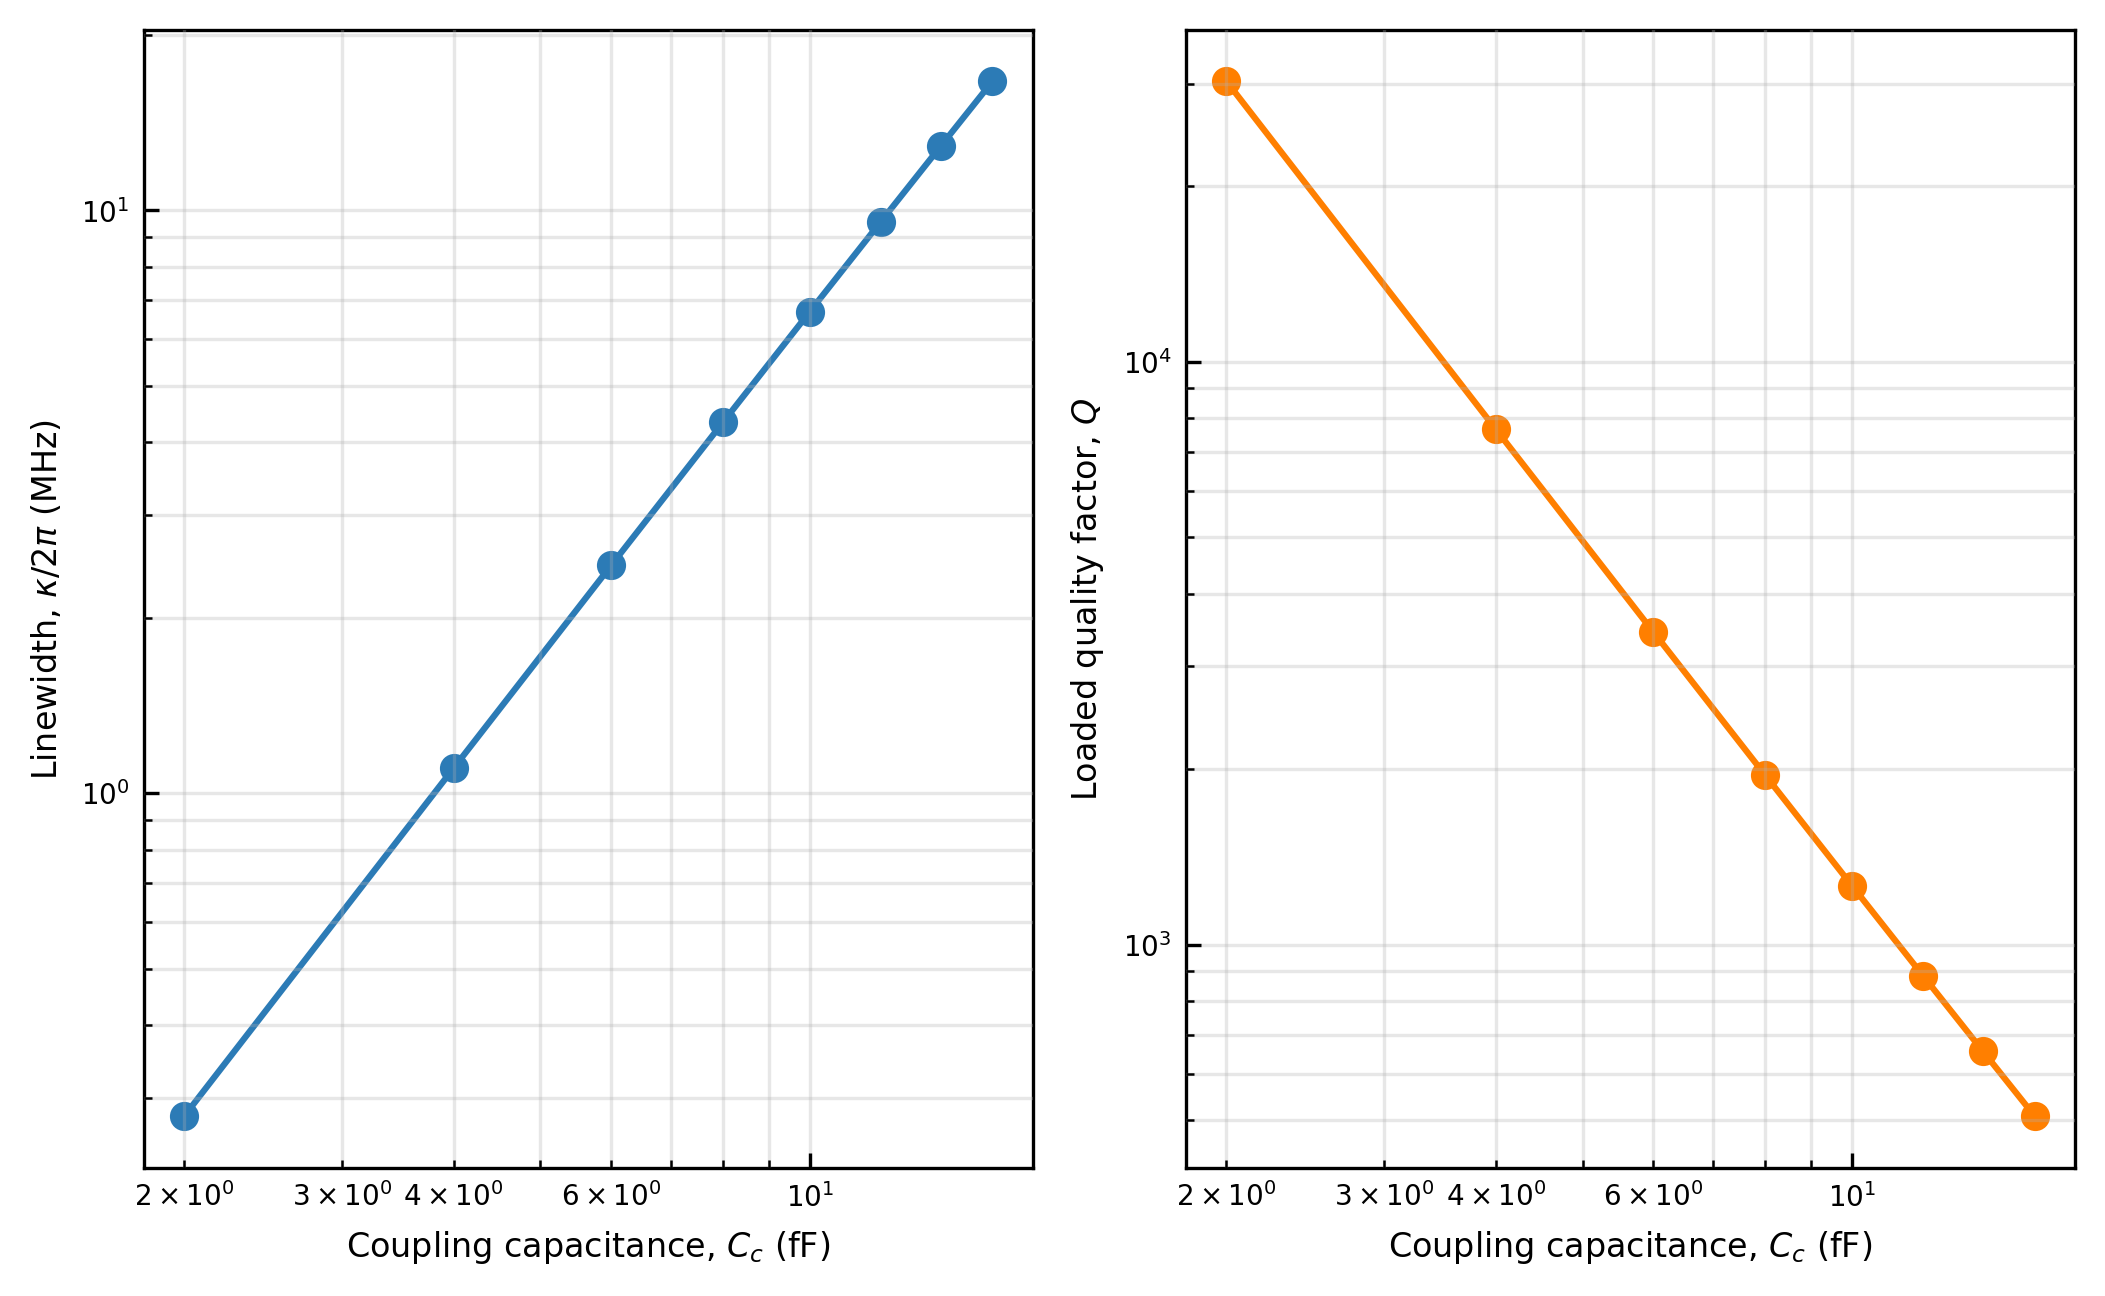

(<Figure size 2117.1x1308.44 with 2 Axes>,
 array([<Axes: xlabel='Coupling capacitance, $C_c$ (fF)', ylabel='Linewidth, $\\kappa/2\\pi$ (MHz)'>,
        <Axes: xlabel='Coupling capacitance, $C_c$ (fF)', ylabel='Loaded quality factor, $Q$'>],
       dtype=object))

In [7]:
sl.plot_curve_pair(
    Cc_values * 1e15, kappas, Qs,
    xlabel=sl.LABEL_CC,
    ylabel0=sl.LABEL_KAPPA,
    ylabel1=sl.axis_label("Loaded quality factor", "Q"),
    xscale="log", yscale="log",
)


Indeed the graph matches our expectations. To quantify it, we can fit a line in log-log space.


In [ ]:
slope_k = np.polyfit(np.log(Cc_values), np.log(kappas), 1)[0]
slope_Q = np.polyfit(np.log(Cc_values), np.log(Qs), 1)[0]
print("kappa  ~  Cc^{:+.2f}   (expected +2)".format(slope_k))
print("Q      ~  Cc^{:+.2f}   (expected -2)".format(slope_Q))


kappa  ~  Cc^+1.97   (expected +2)
Q      ~  Cc^-1.97   (expected -2)


The fitted exponents sit close to $\pm 2$, confirming that $\kappa$ and $Q$ scale with $C_c$ as expected. 

This fitted curve is now the curve we can design against. WE can pick the $C_c$ that lands the
readout resonator at the $\kappa$ (equivalently $Q$) we want. 


## 3c. Reading off a coupling for a target $Q$

Because $Q$ is monotonic in $C_c$, you can interpolate the sweep to size the
coupling capacitor for a chosen quality factor. Here, let's set the target $Q$ to be $5000$.


In [ ]:
target_Q = 5000
Cc_target = sl.invert_monotonic(Cc_values, Qs, target_Q, log=True)
print("For a loaded Q of {}, choose  Cc ~ {:.2f} fF".format(target_Q, Cc_target * 1e15))


For a loaded Q of 5000, choose  Cc ~ 4.96 fF


Now as described in Tutorial 4, we can invert the $Cc$ graph to match the target.


In [ ]:
Cc_target = sl.invert_monotonic(Cc_values, Qs, target_Q, log=True)
print("For a loaded Q of {}, choose  Cc ~ {:.2f} fF".format(target_Q, Cc_target * 1e15))


We now have a way to convert lumped parameters into design targets.

## Next up

In Tutorial 7 we will learn how to use these principles taught in this tutorial to hit a target frequency and target $Q$ simultaneously by
choosing the resonator length and coupling together.
